In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad

In [8]:
pretrain = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/pretrain.h5ad")
f_train = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/downstream_train.h5ad")
f_test = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/downstream_test.h5ad")


/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
import numpy as np
from scipy import sparse

def compute_prevalence(data):
    X = data.X

    if sparse.issparse(X):
        # count nonzeros per column
        nonzero_counts = X.getnnz(axis=0)
    else:
        nonzero_counts = np.count_nonzero(X, axis=0)

    # compute ratio
    prevalence = nonzero_counts / data.n_obs

    # store in var
    data.var["prevalence"] = prevalence

compute_prevalence(pretrain)
compute_prevalence(f_train)
compute_prevalence(f_test)

<Axes: >

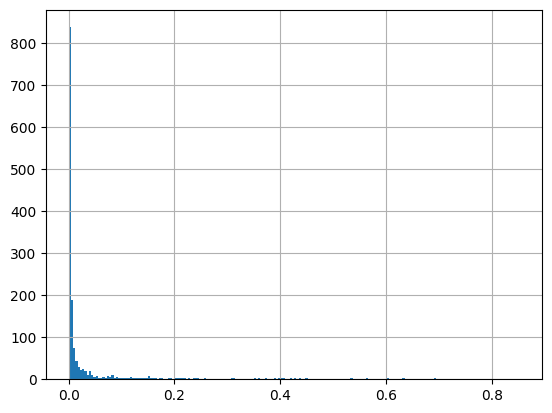

In [ ]:
pretrain.var["prevalence"].hist(bins=200)

In [13]:
# filter 10%–15%
mask = (
    (pretrain.var["prevalence"] >= 0.10) &
    (pretrain.var["prevalence"] <= 0.15)
)

taxa_10_15 = pretrain.var.loc[mask, "taxa"].tolist()

taxa_10_15

['Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia',
 'Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus',
 'Archaea.Methanobacteriota.Methanobacteria.Methanobacteriales.Methanobacteriaceae.Methanobrevibacter',
 'Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelatoclostridiaceae.Catenibacterium',
 'Bacteria.Bacillota.Clostridia.Peptostreptococcales-Tissierellales.Anaerovoracaceae.Mogibacterium',
 'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Incertae Sedis',
 'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Slackia',
 'Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelatoclostridiaceae.Massiliomicrobiota',
 'Bacteria.Bacillota.Clostridia.Oscillospirales.Ruminococcaceae.Fournierella',
 'Bacteria.Bacteroidota.Bacteroidia.Bacteroidales.Prevotellaceae.Leyella',
 'Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Solobacterium',
 'Bacteria.Bacillota.

In [14]:
f_train

AnnData object with n_obs × n_vars = 23511 × 1514
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument', 'downstream_task', 'categorical_label', 'continuous_label'
    var: 'prevalence'
    varm: 'taxonomy'

In [15]:
# keep only taxa that actually exist in f_train
taxa_in_train = [t for t in taxa_10_15 if t in f_train.var_names]

# get their prevalence
train_prevalence = f_train.var.loc[taxa_in_train, "prevalence"]

print(train_prevalence.head())

Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia                  0.060440
Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus                        0.105908
Archaea.Methanobacteriota.Methanobacteria.Methanobacteriales.Methanobacteriaceae.Methanobrevibacter    0.219217
Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelatoclostridiaceae.Catenibacterium                0.070435
Bacteria.Bacillota.Clostridia.Peptostreptococcales-Tissierellales.Anaerovoracaceae.Mogibacterium       0.086981
Name: prevalence, dtype: float64


In [16]:
# keep only taxa that actually exist in f_train
taxa_in_test = [t for t in taxa_10_15 if t in f_test.var_names]

# get their prevalence
test_prevalence = f_test.var.loc[taxa_in_test, "prevalence"]

print(test_prevalence.head())

Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia                  0.091954
Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus                        0.067323
Archaea.Methanobacteriota.Methanobacteria.Methanobacteriales.Methanobacteriaceae.Methanobrevibacter    0.228900
Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelatoclostridiaceae.Catenibacterium                0.122824
Bacteria.Bacillota.Clostridia.Peptostreptococcales-Tissierellales.Anaerovoracaceae.Mogibacterium       0.086371
Name: prevalence, dtype: float64


now, in the pretrain anndata, get the prevalence of the taxa that havethe same family as those. taxonomy info is stored in varm['taxonomy'], and print out the abundance sorted by original taxa from the above list

In [18]:
import numpy as np
import pandas as pd
from scipy import sparse

# ---- 0) your seed taxa, in the same order as your list ----
seed_taxa = [
    "Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia",
    "Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus",
    "Archaea.Methanobacteriota.Methanobacteria.Methanobacteriales.Methanobacteriaceae.Methanobrevibacter",
    "Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelatoclostridiaceae.Catenibacterium",
    "Bacteria.Bacillota.Clostridia.Peptostreptococcales-Tissierellales.Anaerovoracaceae.Mogibacterium",
]

# ---- 1) taxonomy table ----
tax = pretrain.varm["taxonomy"]
# ensure it's a DataFrame aligned to var_names
if not isinstance(tax, pd.DataFrame):
    tax = pd.DataFrame(tax, index=pretrain.var_names)

# helper: get family for a taxon (prefer taxonomy column, fallback parse from string)
def get_family(taxon: str) -> str:
    if taxon in tax.index:
        for col in ["family", "Family", "tax_family", "taxon_family"]:
            if col in tax.columns:
                val = tax.loc[taxon, col]
                if pd.notna(val) and str(val).strip() != "":
                    return str(val)
    # fallback: parse from dotted string: Domain.Phylum.Class.Order.Family.Genus...
    parts = taxon.split(".")
    return parts[4] if len(parts) >= 5 else None

seed_families = {t: get_family(t) for t in seed_taxa}

# ---- 2) get / compute pretrain prevalence ----
if "prevalence" in pretrain.var.columns:
    pre_prev = pretrain.var["prevalence"].astype(float)
else:
    X = pretrain.X
    if sparse.issparse(X):
        nnz = X.getnnz(axis=0)
    else:
        nnz = np.count_nonzero(X, axis=0)
    pre_prev = pd.Series(nnz / pretrain.n_obs, index=pretrain.var_names, name="prevalence")
    pretrain.var["prevalence"] = pre_prev

# ---- 3) compute mean abundance (optional but useful) ----
X = pretrain.X
if sparse.issparse(X):
    mean_abund = np.asarray(X.mean(axis=0)).ravel()
else:
    mean_abund = X.mean(axis=0)
pre_mean = pd.Series(mean_abund, index=pretrain.var_names, name="mean_abundance")
pretrain.var["mean_abundance"] = pre_mean

# ---- 4) build result table: all taxa in same family as each seed ----
rows = []
for seed in seed_taxa:
    fam = seed_families.get(seed, None)
    if fam is None:
        continue

    # select taxa in same family
    if any(c in tax.columns for c in ["family", "Family", "tax_family", "taxon_family"]):
        fam_col = next(c for c in ["family", "Family", "tax_family", "taxon_family"] if c in tax.columns)
        fam_mask = (tax[fam_col].astype(str) == str(fam))
        fam_taxa = tax.index[fam_mask]
    else:
        # fallback parse over var_names
        fam_taxa = [t for t in pretrain.var_names if (t.split(".")[4] if len(t.split(".")) >= 5 else None) == fam]

    for t in fam_taxa:
        rows.append({
            "seed_taxon": seed,
            "family": fam,
            "taxon": t,
            "pretrain_prevalence": float(pre_prev.loc[t]),
            "pretrain_mean_abundance": float(pre_mean.loc[t]),
        })

res = pd.DataFrame(rows)

# ---- 5) sort by original seed order, then within-family by prevalence (or abundance) ----
seed_order = pd.Categorical(res["seed_taxon"], categories=seed_taxa, ordered=True)
res = res.assign(seed_taxon_order=seed_order).sort_values(
    ["seed_taxon_order", "pretrain_prevalence"],
    ascending=[True, False],
).drop(columns=["seed_taxon_order"])

# print (you can also display(res) in notebooks)
print(res.to_string(index=False))

                                                                                         seed_taxon                    family                                                                                                           taxon  pretrain_prevalence  pretrain_mean_abundance
              Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia           Eggerthellaceae                             Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Eggerthella             0.314758                66.956476
              Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia           Eggerthellaceae                         Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Asaccharobacter             0.174633                41.632438
              Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia           Eggerthellaceae                       

based on this, I can safely censor these seed_taxa

In [20]:
# check which seed taxa are actually present
existing = [t for t in seed_taxa if t in pretrain.var_names]
missing = [t for t in seed_taxa if t not in pretrain.var_names]

print("Found:", len(existing))
print("Missing:", missing)

Found: 5
Missing: []


In [21]:
# keep everything NOT in seed_taxa
mask = ~pretrain.var_names.isin(existing)

pretrain_filtered = pretrain[:, mask].copy()

In [22]:
pretrain_filtered

AnnData object with n_obs × n_vars = 106469 × 1509
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument'
    var: 'taxa', 'prevalence', 'mean_abundance'
    varm: 'taxonomy'

In [23]:
pretrain_filtered.write("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/pretrain_censored.h5ad")

now inspect vocab to ensure it is pickled right

In [2]:
import sys
sys.path.append("/home/kchen/microbiome/gut_microbiome_GPT")

In [7]:
import pickle

path = "/home/kchen/microbiome/gut_microbiome_GPT/outputs/pretrain_censored/taxa_vocab.pkl"

with open(path, "rb") as f:
    taxa_vocab = pickle.load(f)

print(type(taxa_vocab))

<class 'data_utils.vocabs.TaxaVocabulary'>


In [8]:
len(taxa_vocab.taxa_names)

1509

It's the correct length